# Agricultural Price Forecasting 
Forecast average monthly prices for the next 12 months using historical price data.

In [1]:
#Importing required libraries

import warnings
warnings.filterwarnings("ignore")

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time series decomposition and forecasting
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Machine learning metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Model saving
import pickle
import os

In [2]:
# Loading the dataset

df = pd.read_csv("price_data.csv")

# Display first 5 rows
df.head()

,date,avg_monthly_price
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


In [3]:
# Checking shape, columns, and data types

print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape of dataset: (249, 2)

Columns: ['date', 'avg_monthly_price']

Data types:
date                 object
avg_monthly_price     int64
dtype: object


In [4]:
#  Converting the date column to datetime format

df["date"] = pd.to_datetime(df["date"])

# Sort data in chronological order
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,avg_monthly_price
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


In [6]:
#  Check missing values and duplicate rows

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
date                 0
avg_monthly_price    0
dtype: int64

Duplicate rows: 0


In [7]:
#  Removing duplicate rows if present

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (249, 2)


In [8]:
# summary statistics for price column

df["avg_monthly_price"].describe()

count      249.000000
mean      7918.891566
std       2804.992684
min       3500.000000
25%       6123.000000
50%       7250.000000
75%       9783.000000
max      16163.000000
Name: avg_monthly_price, dtype: float64

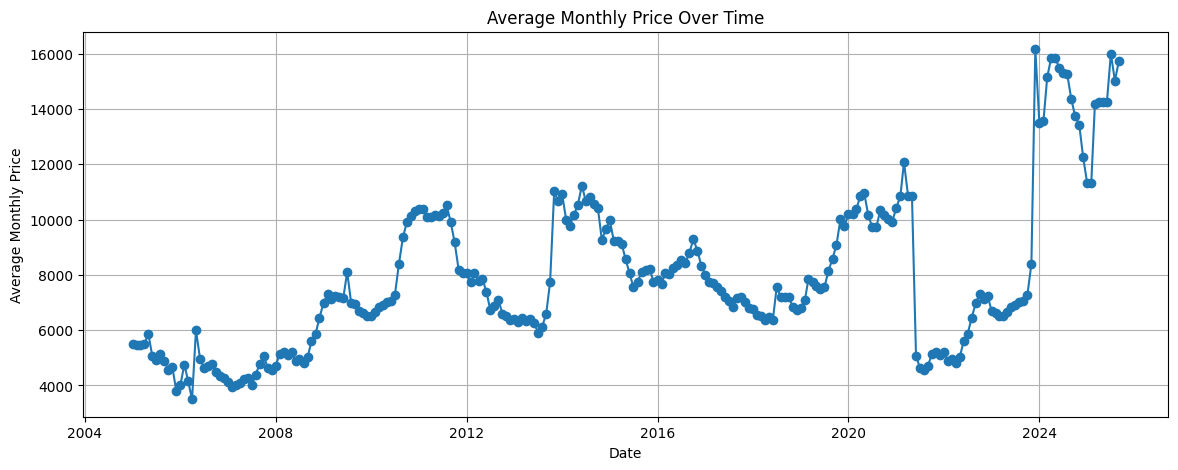

In [9]:
# Visualizing the monthly price trend

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["avg_monthly_price"], marker="o")
plt.title("Average Monthly Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Monthly Price")
plt.grid(True)
plt.show()

In [10]:
#  Setting date column as index for time series operations

df_ts = df.copy()
df_ts.set_index("date", inplace=True)

df_ts.head()

,avg_monthly_price
date,
2005-01-01,5500
2005-02-01,5476
2005-03-01,5466
2005-04-01,5487
2005-05-01,5876


In [11]:
# Ensuring data follows monthly frequency

df_ts = df_ts.asfreq("MS")   # MS = Month Start frequency

print(df_ts.head(12))
print("\nMissing values after setting monthly frequency:")
print(df_ts.isnull().sum())

            avg_monthly_price
date                         
2005-01-01               5500
2005-02-01               5476
2005-03-01               5466
2005-04-01               5487
2005-05-01               5876
2005-06-01               5058
2005-07-01               4919
2005-08-01               5149
2005-09-01               4899
2005-10-01               4562
2005-11-01               4665
2005-12-01               3813

Missing values after setting monthly frequency:
avg_monthly_price    0
dtype: int64


In [12]:
# Handlinh missing values after frequency alignment

# Forward fill is acceptable for monthly price series if gaps are small
df_ts["avg_monthly_price"] = df_ts["avg_monthly_price"].fillna(method="ffill")

print("Missing values after filling:")
print(df_ts.isnull().sum())

Missing values after filling:
avg_monthly_price    0
dtype: int64


In [13]:
#  Detecting outliers using IQR method

Q1 = df_ts["avg_monthly_price"].quantile(0.25)
Q3 = df_ts["avg_monthly_price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_ts[
    (df_ts["avg_monthly_price"] < lower_bound) |
    (df_ts["avg_monthly_price"] > upper_bound)
]

print("Number of outliers detected:", len(outliers))
outliers.head()

Number of outliers detected: 7


,avg_monthly_price
date,
2023-12-01,16163
2024-04-01,15863
2024-05-01,15863
2024-06-01,15488
2024-07-01,15294


In [14]:
# Capping extreme values instead of deleting them
# This is safer in time series because deleting rows can break the sequence.

df_ts["avg_monthly_price_clean"] = df_ts["avg_monthly_price"].clip(lower=lower_bound, upper=upper_bound)

df_ts[["avg_monthly_price", "avg_monthly_price_clean"]].head()

,avg_monthly_price,avg_monthly_price_clean
date,,
2005-01-01,5500,5500
2005-02-01,5476,5476
2005-03-01,5466,5466
2005-04-01,5487,5487
2005-05-01,5876,5876


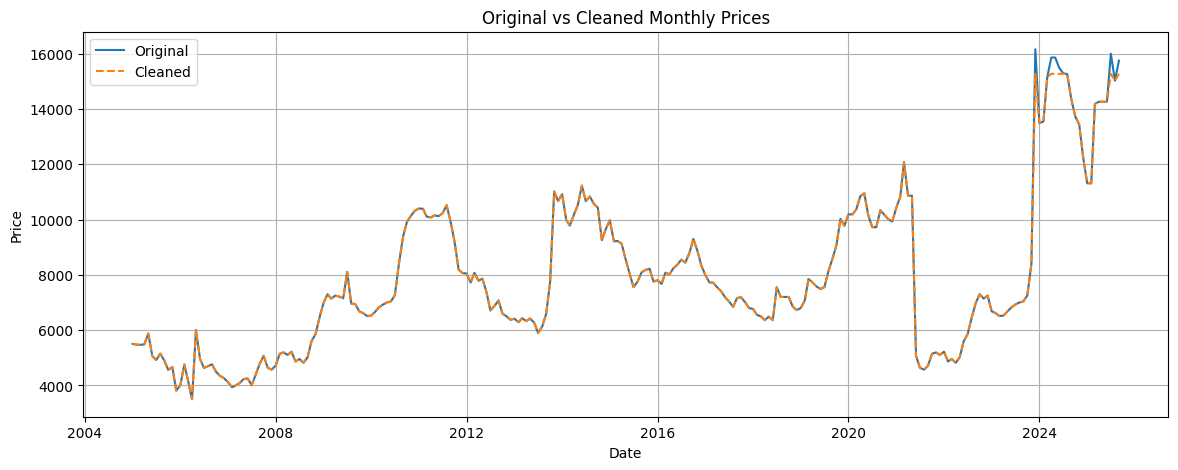

In [15]:
# Comparing original and cleaned price series

plt.figure(figsize=(14, 5))
plt.plot(df_ts.index, df_ts["avg_monthly_price"], label="Original")
plt.plot(df_ts.index, df_ts["avg_monthly_price_clean"], label="Cleaned", linestyle="--")
plt.title("Original vs Cleaned Monthly Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

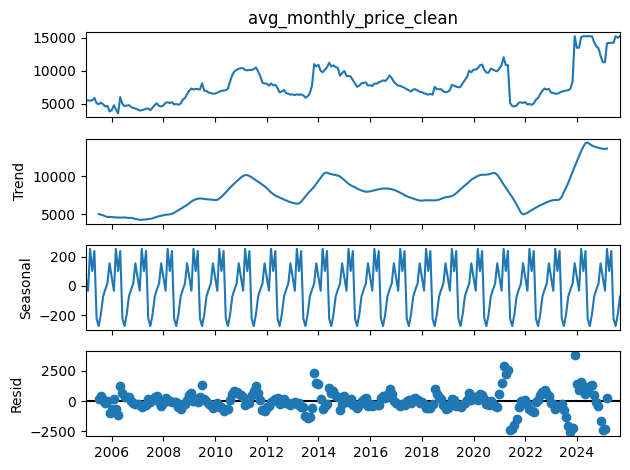

In [16]:
# Decomposing the series into trend, seasonality, and residuals

decomposition = seasonal_decompose(df_ts["avg_monthly_price_clean"], model="additive", period=12)
decomposition.plot()
plt.show()

In [17]:
# Checking whether the series is stationary using ADF test

adf_result = adfuller(df_ts["avg_monthly_price_clean"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

ADF Statistic: -1.552873077518641
p-value: 0.5072127429094699
The series is not stationary.


In [18]:
#  Splitting the data into training and testing sets
# Last 12 months will be used as the test set

train = df_ts.iloc[:-12]
test = df_ts.iloc[-12:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (237, 2)
Test shape: (12, 2)


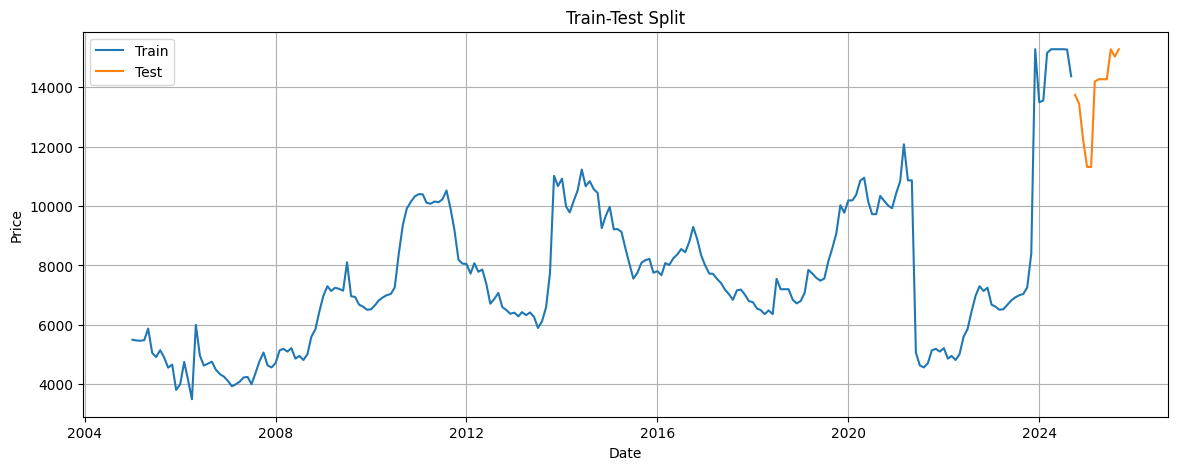

In [19]:
#  Visualizinh the training and testing periods

plt.figure(figsize=(14, 5))
plt.plot(train.index, train["avg_monthly_price_clean"], label="Train")
plt.plot(test.index, test["avg_monthly_price_clean"], label="Test")
plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
#  Train SARIMA model
# order=(p,d,q)
# seasonal_order=(P,D,Q,s) where s=12 for monthly seasonality

model = SARIMAX(
    train["avg_monthly_price_clean"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:            avg_monthly_price_clean   No. Observations:                  237
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1710.261
Date:                            Sat, 21 Mar 2026   AIC                           3430.522
Time:                                    21:17:27   BIC                           3447.257
Sample:                                01-01-2005   HQIC                          3437.287
                                     - 09-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4447      1.989      0.224      0.823      -3.454       4.343
ma.L1         -0.4043      2.001   

In [21]:
#  Predicting prices for the test period

test_forecast = results.forecast(steps=12)

test_forecast

2024-10-01    14489.690565
2024-11-01    14579.884044
2024-12-01    14948.015186
2025-01-01    14895.798214
2025-02-01    14821.592543
2025-03-01    15121.334892
2025-04-01    15003.531716
2025-05-01    15106.188216
2025-06-01    14509.977736
2025-07-01    14497.889379
2025-08-01    14613.079879
2025-09-01    14779.952415
Freq: MS, Name: predicted_mean, dtype: float64

In [22]:
# Creating comparison dataframe

comparison = pd.DataFrame({
    "Actual": test["avg_monthly_price_clean"],
    "Predicted": test_forecast
})

comparison

,Actual,Predicted
2024-10-01,13738,14489.690565
2024-11-01,13438,14579.884044
2024-12-01,12250,14948.015186
2025-01-01,11313,14895.798214
2025-02-01,11313,14821.592543
2025-03-01,14188,15121.334892
2025-04-01,14263,15003.531716
2025-05-01,14263,15106.188216
2025-06-01,14263,14509.977736
2025-07-01,15273,14497.889379


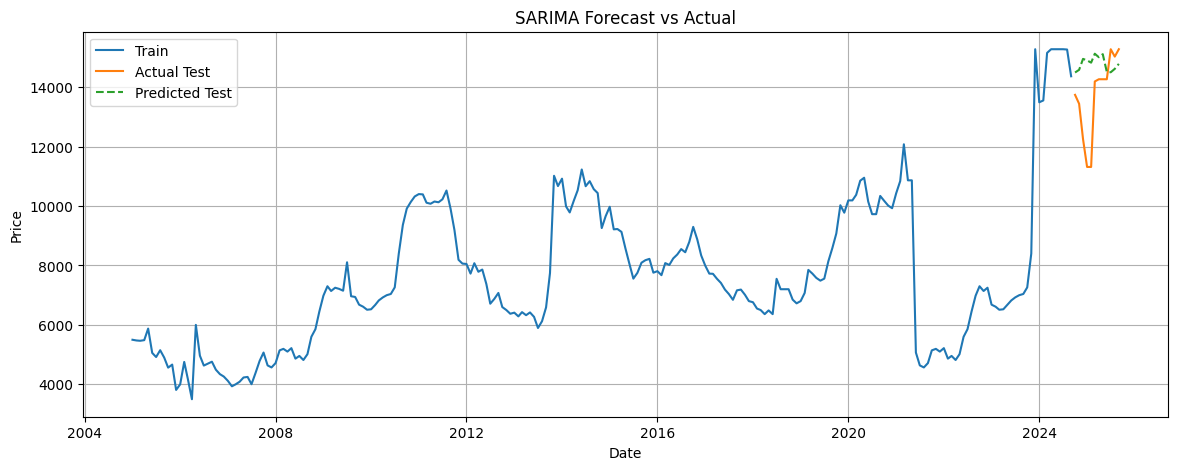

In [23]:
# Ploting test predictions against actual values

plt.figure(figsize=(14, 5))
plt.plot(train.index, train["avg_monthly_price_clean"], label="Train")
plt.plot(test.index, test["avg_monthly_price_clean"], label="Actual Test")
plt.plot(test.index, test_forecast, label="Predicted Test", linestyle="--")
plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
#  Evaluating model performance

mae = mean_absolute_error(test["avg_monthly_price_clean"], test_forecast)
rmse = np.sqrt(mean_squared_error(test["avg_monthly_price_clean"], test_forecast))
mape = mean_absolute_percentage_error(test["avg_monthly_price_clean"], test_forecast) * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE : 1343.92
RMSE: 1767.77
MAPE: 10.76 %


In [25]:
# Training the model again using the full cleaned dataset
# This final model will be used for future 12-month forecasting

final_model = SARIMAX(
    df_ts["avg_monthly_price_clean"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit()

In [26]:
#  Predicting next 12 months

future_forecast = final_results.forecast(steps=12)

future_forecast

2025-10-01    15424.541557
2025-11-01    15588.045245
2025-12-01    16331.705793
2026-01-01    16135.329755
2026-02-01    16075.237415
2026-03-01    16560.521920
2026-04-01    16465.138024
2026-05-01    16555.789379
2026-06-01    16015.654032
2026-07-01    16043.651458
2026-08-01    16137.598238
2026-09-01    16239.164864
Freq: MS, Name: predicted_mean, dtype: float64

In [27]:
# Creating proper future monthly dates for forecast output

last_date = df_ts.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq="MS")

forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast_price": future_forecast.values
})

forecast_df

,date,forecast_price
0,2025-10-01,15424.541557
1,2025-11-01,15588.045245
2,2025-12-01,16331.705793
3,2026-01-01,16135.329755
4,2026-02-01,16075.237415
5,2026-03-01,16560.521920
6,2026-04-01,16465.138024
7,2026-05-01,16555.789379
8,2026-06-01,16015.654032
9,2026-07-01,16043.651458


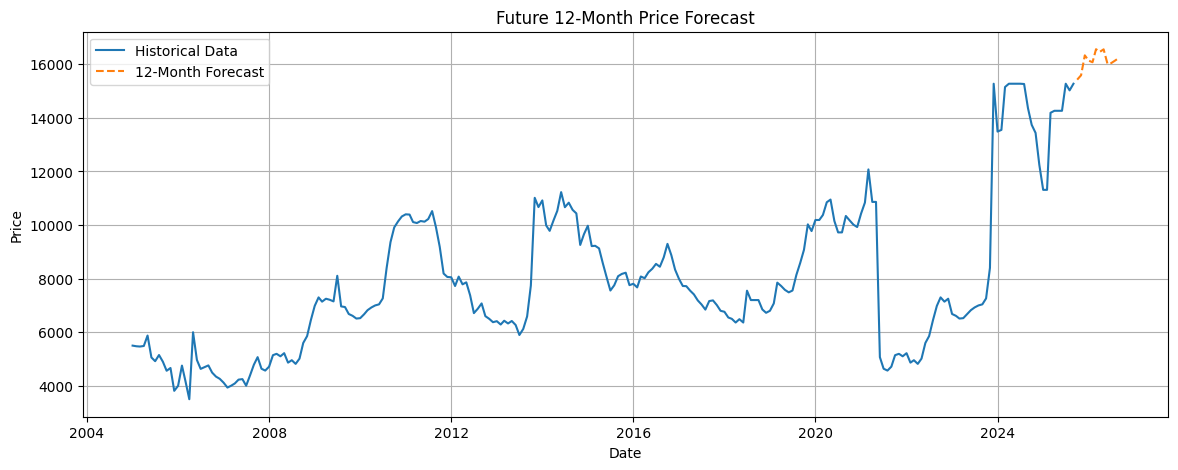

In [28]:
#Visualizing historical data and 12-month future forecast

plt.figure(figsize=(14, 5))
plt.plot(df_ts.index, df_ts["avg_monthly_price_clean"], label="Historical Data")
plt.plot(forecast_df["date"], forecast_df["forecast_price"], label="12-Month Forecast", linestyle="--")
plt.title("Future 12-Month Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Saving the trained model for deployment

os.makedirs("model_artifacts", exist_ok=True)

with open("model_artifacts/sarima_model.pkl", "wb") as f:
    pickle.dump(final_results, f)

print("Model saved successfully.")

Model saved successfully.


Business Actions Based on Forecast

Based on the predicted price trends, a company can take the following actions:
If prices are expected to increase, the company can purchase inventory in advance to minimize procurement costs.
If prices are expected to decrease, the company can delay purchasing decisions to benefit from lower prices.
Optimize inventory management by maintaining adequate stock during high-demand or high-price periods.
Improve supply chain planning by aligning procurement strategies with forecasted price trends.
Use predictions to inform pricing strategies, budgeting, and financial planning.

These actions help in reducing costs and improving operational efficiency.

In [32]:

django_code = """
# views.py

import pickle
from django.http import JsonResponse

with open('model_artifacts/sarima_model.pkl', 'rb') as f:
    model = pickle.load(f)

def predict_prices(request):
    forecast = model.forecast(steps=12)
    return JsonResponse({
        'forecast': list(map(float, forecast))
    })
"""

print(django_code)


# views.py

import pickle
from django.http import JsonResponse

with open('model_artifacts/sarima_model.pkl', 'rb') as f:
    model = pickle.load(f)

def predict_prices(request):
    forecast = model.forecast(steps=12)
    return JsonResponse({
        'forecast': list(map(float, forecast))
    })



In [33]:


fastapi_code = """
from fastapi import FastAPI
import pickle

app = FastAPI()

with open('model_artifacts/sarima_model.pkl', 'rb') as f:
    model = pickle.load(f)

@app.get('/predict')
def predict():
    forecast = model.forecast(steps=12)
    return {'forecast': list(map(float, forecast))}
"""

print(fastapi_code)


from fastapi import FastAPI
import pickle

app = FastAPI()

with open('model_artifacts/sarima_model.pkl', 'rb') as f:
    model = pickle.load(f)

@app.get('/predict')
def predict():
    forecast = model.forecast(steps=12)
    return {'forecast': list(map(float, forecast))}



## Conclusion

In this project, a time series model was developed to forecast average monthly prices using historical data. The dataset was cleaned by handling missing values, removing duplicates, and treating outliers to ensure reliable input for the model.

A SARIMA model was used because it works well for monthly time series data and can capture both trend and seasonal patterns. The model was trained and evaluated using metrics such as MAE, RMSE, and MAPE, and it was able to produce reasonable predictions.

The model was then used to forecast prices for the next 12 months. These predictions can help in making better decisions related to purchasing, inventory, and planning.
